# 🔤 Notebook 2: Tokenization & Vocabulary

Prepares the raw caption CSV for training. Three big fixes vs the previous version:

| Issue in v1 | Fix in v2 |
|---|---|
| **Test set was biased to LOW-quality captions** (test mean q=0.32, train q=0.68 from `smart_split`) — your BLEU was unfair | **Random split by image_id**, no quality stratification. Quality is used only as a filter. |
| **49,408-token CLIP vocab → enormous output layer** (49K × 512 = 25M params overfitting on ~13K samples) | **Reduced vocab built from corpus**: keep only CLIP tokens that appear ≥ `MIN_FREQ` times. Typically shrinks to ~5–8K tokens. We save a `local_id ↔ clip_id` mapping. |
| **No filtering** — 45% of captions had length-delta > 15 words, 71% had quality < 0.7 | **Hard filter** applied: drop rows with quality < 0.5, length-delta > 12, neutral > 25 words, or vocab overlap < 0.25. |

## Inputs

- A CSV from Notebook 1 (or your existing v1 CSV — both work)

## Outputs (all to `/kaggle/working/`)

- `train.csv`, `val.csv`, `test.csv` — random splits by image_id
- `processed_captions.pkl` — flat list of dicts with `local_token_ids` and `neutral_local_token_ids`
- `vocab_mapping.pkl` — dict with `local2clip`, `clip2local`, `vocab_size`, special token IDs


## ⚙️ Step 1: Setup

In [42]:
import shutil
import os
# Define source and destination
source_file = '/kaggle/input/datasets/muhammadasjadali/emotionedcaptions8k/emotion_captions (3) (1).csv'
destination_file = '/kaggle/working/emotion_captions.csv'
# Copy a single file
shutil.copy(source_file, destination_file)

'/kaggle/working/emotion_captions.csv'

In [46]:
# ════════════════════════════════════════════════════════════════════════════
# Detect sentence-level repetition glitches in neutral captions.
# Read-only diagnostic — no fixing yet.
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
import re
from collections import Counter

CSV_PATH = '/kaggle/working/emotion_captions.csv'

df = pd.read_csv(CSV_PATH)
neutrals = df[['image_id', 'neutral_caption']].drop_duplicates('image_id').copy()
print(f"Scanning {len(neutrals):,} unique neutrals\n")

# ── Sentence splitter (handles the trailing-incomplete-sentence case) ───
def split_sentences(text):
    """Split on ., !, ? — return non-empty stripped sentences (lowercased)."""
    if not isinstance(text, str):
        return []
    parts = re.split(r'[.!?]+', text)
    return [p.strip().lower() for p in parts if p.strip()]

# ── Per-caption stats ───────────────────────────────────────────────────
def repetition_stats(text):
    sents = split_sentences(text)
    if not sents:
        return pd.Series({'n_sents': 0, 'n_unique': 0,
                          'max_repeats': 0, 'rep_ratio': 0.0})
    counts = Counter(sents)
    return pd.Series({
        'n_sents'    : len(sents),
        'n_unique'   : len(counts),
        'max_repeats': max(counts.values()),       # most-repeated sentence count
        'rep_ratio'  : 1 - len(counts) / len(sents),  # 0 = all unique, →1 = all dupes
    })

stats = neutrals['neutral_caption'].apply(repetition_stats)
neutrals = pd.concat([neutrals, stats], axis=1)
neutrals['word_count'] = neutrals['neutral_caption'].astype(str).str.split().str.len()

# ── Tier breakdown ──────────────────────────────────────────────────────
print(f"{'═'*70}")
print("SENTENCE-LEVEL REPETITION TIERS")
print('═'*70)
print(f"  {'Severity':<40} {'#imgs':>10} {'%':>7} {'avg_words':>11}")
print('  ' + '─'*68)
tiers = [
    ('clean (max_repeats == 1)',           neutrals['max_repeats'] == 1),
    ('mild (max_repeats == 2)',            neutrals['max_repeats'] == 2),
    ('moderate (max_repeats 3–4)',         neutrals['max_repeats'].between(3, 4)),
    ('heavy (max_repeats 5–9)',            neutrals['max_repeats'].between(5, 9)),
    ('severe (max_repeats ≥ 10)',          neutrals['max_repeats'] >= 10),
]
for label, mask in tiers:
    n = mask.sum()
    pct = n / len(neutrals) * 100
    avg_w = neutrals.loc[mask, 'word_count'].mean() if n else 0
    print(f"  {label:<40} {n:>10,} {pct:>6.1f}% {avg_w:>11.1f}")

# ── Glitched vs clean length comparison ─────────────────────────────────
glitched_mask = neutrals['max_repeats'] >= 2
clean_mask    = neutrals['max_repeats'] == 1

print(f"\n{'═'*70}")
print("LENGTH: GLITCHED (≥2 repeats) vs CLEAN")
print('═'*70)
for label, mask in [('clean', clean_mask), ('glitched', glitched_mask)]:
    s = neutrals.loc[mask, 'word_count']
    if len(s):
        print(f"  {label:<10}  n={len(s):>6,}  "
              f"mean={s.mean():5.1f}  median={s.median():5.1f}  "
              f"p95={s.quantile(0.95):5.1f}  max={s.max()}")

# How many of the glitched are also "long"?
for thresh in [25, 35, 50, 100]:
    n_long_glitch = ((glitched_mask) & (neutrals['word_count'] > thresh)).sum()
    n_long_total  = (neutrals['word_count'] > thresh).sum()
    print(f"  > {thresh} words: {n_long_glitch:,} glitched / {n_long_total:,} total long")

# ── Worst offenders ─────────────────────────────────────────────────────
print(f"\n{'═'*70}")
print("WORST 5 (most-repeated sentence, most words)")
print('═'*70)
worst = neutrals.nlargest(5, ['max_repeats', 'word_count'])
for _, r in worst.iterrows():
    print(f"\n  {r['image_id']}  "
          f"({r['n_sents']} sents, {r['n_unique']} unique, "
          f"max_repeats={r['max_repeats']}, {r['word_count']}w)")
    print(f"    {str(r['neutral_caption'])[:200]}{'...' if len(str(r['neutral_caption']))>200 else ''}")

# ── Mild cases (just to see what max_repeats=2 looks like — might be benign) ──
print(f"\n{'═'*70}")
print("3 RANDOM 'MILD' CASES (max_repeats == 2) — sanity check these aren't false positives")
print('═'*70)
mild = neutrals[neutrals['max_repeats'] == 2].sample(min(3, (neutrals['max_repeats']==2).sum()), random_state=0)
for _, r in mild.iterrows():
    print(f"\n  {r['image_id']}  ({r['n_sents']} sents, {r['word_count']}w)")
    print(f"    {str(r['neutral_caption'])[:250]}")

# Save the per-image stats so the next script (the fixer) can use them
neutrals.to_csv('/kaggle/working/neutral_repetition_stats.csv', index=False)
print(f"\n✅ Saved per-image stats → /kaggle/working/neutral_repetition_stats.csv")

Scanning 7,945 unique neutrals

══════════════════════════════════════════════════════════════════════
SENTENCE-LEVEL REPETITION TIERS
══════════════════════════════════════════════════════════════════════
  Severity                                      #imgs       %   avg_words
  ────────────────────────────────────────────────────────────────────
  clean (max_repeats == 1)                      7,849   98.8%        38.4
  mild (max_repeats == 2)                          95    1.2%        50.3
  moderate (max_repeats 3–4)                        0    0.0%         0.0
  heavy (max_repeats 5–9)                           0    0.0%         0.0
  severe (max_repeats ≥ 10)                         0    0.0%         0.0

══════════════════════════════════════════════════════════════════════
LENGTH: GLITCHED (≥2 repeats) vs CLEAN
══════════════════════════════════════════════════════════════════════
  clean       n= 7,849  mean= 38.4  median= 37.0  p95= 60.0  max=259
  glitched    n=    95  mean

In [45]:
# ════════════════════════════════════════════════════════════════════════════
# Drop images with sentence-level repetition glitches (max_repeats ≥ 3).
# Reads the diagnostic CSV produced by the previous cell.
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
import shutil

CSV_PATH    = '/kaggle/working/emotion_captions.csv'
STATS_PATH  = '/kaggle/working/neutral_repetition_stats.csv'
BACKUP_PATH = CSV_PATH.replace('.csv', '_BACKUP_before_repdrop.csv')

DROP_THRESHOLD = 3   # drop images whose neutral has any sentence repeated ≥ 3 times

# ── Load ────────────────────────────────────────────────────────────────
df    = pd.read_csv(CSV_PATH)
stats = pd.read_csv(STATS_PATH)

bad_ids = set(stats.loc[stats['max_repeats'] >= DROP_THRESHOLD, 'image_id'])
print(f"Flagging {len(bad_ids):,} images (max_repeats ≥ {DROP_THRESHOLD})")

# Show breakdown by tier so you can confirm
tier_breakdown = stats[stats['image_id'].isin(bad_ids)].copy()
tier_breakdown['tier'] = pd.cut(
    tier_breakdown['max_repeats'],
    bins=[2, 4, 9, float('inf')],
    labels=['moderate (3–4)', 'heavy (5–9)', 'severe (≥10)']
)
print("\nDrops by tier:")
print(tier_breakdown['tier'].value_counts().sort_index().to_string())

# ── Backup + drop ───────────────────────────────────────────────────────
shutil.copy2(CSV_PATH, BACKUP_PATH)
print(f"\n📦 Backup → {BACKUP_PATH}")

n_before_rows = len(df)
n_before_imgs = df['image_id'].nunique()
df_keep = df[~df['image_id'].isin(bad_ids)]
df_keep.to_csv(CSV_PATH, index=False)

print(f"🗑  Removed {n_before_rows - len(df_keep):,} rows "
      f"({n_before_imgs - df_keep['image_id'].nunique():,} images)")
print(f"💾 CSV now has {len(df_keep):,} rows from "
      f"{df_keep['image_id'].nunique():,} images")

Flagging 147 images (max_repeats ≥ 3)

Drops by tier:
tier
moderate (3–4)    56
heavy (5–9)       18
severe (≥10)      73

📦 Backup → /kaggle/working/emotion_captions_BACKUP_before_repdrop.csv
🗑  Removed 735 rows (147 images)
💾 CSV now has 40,375 rows from 7,944 images


In [47]:
import os
import re
import json
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from transformers import CLIPTokenizer

random.seed(42)
np.random.seed(42)

# ── Paths — point INPUT_CSV to whichever caption CSV you want to use ─────────
INPUT_CSV   = '/kaggle/working/emotion_captions.csv'  # or your v2 file
WORKING_DIR = '/kaggle/working'
os.makedirs(WORKING_DIR, exist_ok=True)

# ── Filtering thresholds ─────────────────────────────────────────────────────
MIN_QUALITY      = 0.30    # drop low-quality LLM rewrites
MAX_LENGTH_DELTA = 12      # drop emotion captions that diverge in length
MAX_NEUTRAL_LEN  = 25      # drop overly verbose neutrals (was concat of 5 captions in v1)
MIN_EMOTION_LEN  = 4       # drop near-empty emotion captions
MAX_EMOTION_LEN  = 35
MIN_VOCAB_OVERLAP = 0.20   # require some content-word overlap with neutral

# ── Vocab settings ───────────────────────────────────────────────────────────
MIN_TOKEN_FREQ = 3         # keep CLIP tokens appearing ≥ 3× in corpus
MAX_SEQ_LEN    = 30        # token-level max (CLIP BPE; tighter than v1's 52)

# ── Split ratios — RANDOM, not quality-stratified ────────────────────────────
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

EMOTIONS    = ['humorous', 'joyful', 'romantic', 'sad', 'tense']
EMOTION2ID  = {e: i for i, e in enumerate(EMOTIONS)}

print("✅ Setup done")

✅ Setup done


## 📥 Step 2: Load + Quick Diagnosis

In [48]:
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df):,} rows  ({df['image_id'].nunique():,} unique images)")
print(f"Columns: {df.columns.tolist()}")

# Coerce emotion_id if missing
if 'emotion_id' not in df.columns:
    df['emotion_id'] = df['emotion'].map(EMOTION2ID)

# Quick diagnosis
df['_n_words'] = df['neutral_caption'].astype(str).str.split().str.len()
df['_e_words'] = df['emotion_caption'].astype(str).str.split().str.len()
df['_delta']   = (df['_e_words'] - df['_n_words']).abs()

print(f"\nBefore filtering:")
print(f"  Neutral words — mean: {df['_n_words'].mean():.1f}, max: {df['_n_words'].max()}")
print(f"  Emotion words — mean: {df['_e_words'].mean():.1f}, max: {df['_e_words'].max()}")
if 'quality_score' in df.columns:
    print(f"  Quality       — mean: {df['quality_score'].mean():.2f}")

Loaded 40,375 rows  (7,944 unique images)
Columns: ['image_id', 'img_path', 'neutral_caption', 'emotion', 'emotion_id', 'emotion_caption', 'quality_score']

Before filtering:
  Neutral words — mean: 37.9, max: 259
  Emotion words — mean: 22.1, max: 510
  Quality       — mean: 0.56


## 🧹 Step 3: Clean + Filter

This is the biggest behavioural change vs v1. We drop rows the LLM clearly hallucinated on. If your dataset is small after filtering, loosen the thresholds at the top of this notebook.


In [49]:
# ── Tunable filter thresholds (loosened) ─────────────────────────────────────
MAX_NEUTRAL_LEN   = 60      # was 25 — more headroom for 2-sentence neutrals
MIN_NEUTRAL_LEN   = 3
MIN_EMOTION_LEN   = 6       # matches your 6-word floor from earlier
MAX_EMOTION_LEN   = 50      # matches your 35-word ceiling
MAX_LENGTH_DELTA  = 35      # was 12 — emotion can be a bit longer than neutral
MIN_VOCAB_OVERLAP = 0.03    # was 0.20 — the harsh filter
MIN_QUALITY       = 0.0     # set 0.0 to disable quality_score filter (it's unreliable)
BALANCE_CLASSES   = False    # downsample each emotion to the smallest class size

# ── 3a. Normalise whitespace, lowercase, strip markdown ──────────────────────
def normalize(text):
    text = str(text).strip().lower()
    text = re.sub(r'\*\*(.+?)\*\*', r'\1', text)
    text = re.sub(r'\[(.+?)\]\(.+?\)', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace(' ,', ',').replace(' .', '.').replace(' !', '!').replace(' ?', '?')
    return text

df['neutral_caption'] = df['neutral_caption'].apply(normalize)
df['emotion_caption'] = df['emotion_caption'].apply(normalize)

# ── 3b. Smart multi-sentence truncation ──────────────────────────────────────
# Keep as many leading sentences as fit within MAX_NEUTRAL_LEN words.
# This preserves more content vocab than chopping to the first sentence only.
def smart_truncate(text, max_words):
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    sents = [s for s in sents if s.strip()]
    if not sents:
        return text
    out = ''
    for s in sents:
        candidate = (out + ' ' + s).strip() if out else s
        if len(candidate.split()) > max_words and out:
            break
        out = candidate
    return out

mask_long_neutral = df['neutral_caption'].str.split().str.len() > MAX_NEUTRAL_LEN
df.loc[mask_long_neutral, 'neutral_caption'] = (
    df.loc[mask_long_neutral, 'neutral_caption']
      .apply(lambda x: smart_truncate(x, MAX_NEUTRAL_LEN))
)
print(f"Smart-truncated {mask_long_neutral.sum():,} long neutrals "
      f"(kept as many sentences as fit in ≤{MAX_NEUTRAL_LEN} words)")

# Recompute lengths
df['_n_words'] = df['neutral_caption'].str.split().str.len()
df['_e_words'] = df['emotion_caption'].str.split().str.len()
df['_delta']   = (df['_e_words'] - df['_n_words']).abs()

# ── 3c. Vocab overlap (content words only) ──────────────────────────────────
STOP = set('a an the is are was were be been being am i you he she it we they this '
           'that these those of in on at to for with by from as and or but if while'.split())

def content_words(text):
    return set(w for w in str(text).lower().split() if w not in STOP and w.isalpha())

df['_overlap'] = df.apply(
    lambda r: (
        (lambda n, e: len(n & e) / max(1, len(n)))(
            content_words(r['neutral_caption']),
            content_words(r['emotion_caption']))
    ),
    axis=1
)

# ── 3d. Per-rule drop accounting ────────────────────────────────────────────
n_before = len(df)
rules = {
    f'neutral length ∉ [{MIN_NEUTRAL_LEN},{MAX_NEUTRAL_LEN}]':
        ~df['_n_words'].between(MIN_NEUTRAL_LEN, MAX_NEUTRAL_LEN),
    f'emotion length ∉ [{MIN_EMOTION_LEN},{MAX_EMOTION_LEN}]':
        ~df['_e_words'].between(MIN_EMOTION_LEN, MAX_EMOTION_LEN),
    f'length delta > {MAX_LENGTH_DELTA}':
        df['_delta'] > MAX_LENGTH_DELTA,
    f'overlap < {MIN_VOCAB_OVERLAP}':
        df['_overlap'] < MIN_VOCAB_OVERLAP,
}
if 'quality_score' in df.columns and MIN_QUALITY > 0:
    rules[f'quality_score < {MIN_QUALITY}'] = df['quality_score'] < MIN_QUALITY

print(f"\nDrop reasons (rows that fail each rule, not mutually exclusive):")
for label, mask in rules.items():
    print(f"  {label:<45} {mask.sum():>7,}  ({mask.mean()*100:5.1f}%)")

# ── 3e. Apply combined keep mask ────────────────────────────────────────────
keep_mask = ~pd.concat(rules.values(), axis=1).any(axis=1)
df = df[keep_mask].reset_index(drop=True)

print(f"\nFiltering report:")
print(f"  Before : {n_before:,} rows")
print(f"  After  : {len(df):,} rows  ({len(df)/n_before:.1%} kept)")
print(f"  Images : {df['image_id'].nunique():,}")

print(f"\nRows per emotion after filter:")
print(df['emotion'].value_counts().to_string())

# ── 3f. Class balancing ──────────────────────────────────────────────────────
if BALANCE_CLASSES:
    min_count = df['emotion'].value_counts().min()
    df = (df.groupby('emotion', group_keys=False)
            .apply(lambda g: g.sample(n=min_count, random_state=42),
                   include_groups=False)
            .reset_index(drop=True))
    # Re-attach the emotion column (apply with include_groups=False drops it)
    # Simpler: redo without that flag
    df = pd.read_csv(INPUT_CSV) if False else df  # no-op, just clarity
    # Actually do the rebalance the safe way:
    pass

# Safer balancing implementation (works across pandas versions):
if BALANCE_CLASSES:
    df_full = df  # before downsampling
    min_count = df_full['emotion'].value_counts().min()
    parts = []
    for emo, grp in df_full.groupby('emotion'):
        parts.append(grp.sample(n=min_count, random_state=42))
    df = pd.concat(parts).sort_values('image_id').reset_index(drop=True)

    print(f"\nBalanced to {min_count:,} rows per emotion → {len(df):,} total")
    print(df['emotion'].value_counts().to_string())

Smart-truncated 1,748 long neutrals (kept as many sentences as fit in ≤60 words)

Drop reasons (rows that fail each rule, not mutually exclusive):
  neutral length ∉ [3,60]                           697  (  1.7%)
  emotion length ∉ [6,50]                           910  (  2.3%)
  length delta > 35                               1,354  (  3.4%)
  overlap < 0.03                                  1,537  (  3.8%)

Filtering report:
  Before : 40,375 rows
  After  : 36,910 rows  (91.4% kept)
  Images : 7,762

Rows per emotion after filter:
emotion
joyful      7507
sad         7461
romantic    7399
tense       7339
humorous    7204


## 🎲 Step 4: Random Split by image_id

⚠️  Critical fix: v1 sorted images by quality (descending) and put low-quality images in test. That made BLEU look worse than it should because the test references were noisier. We use a random shuffle instead.


In [50]:
# Random shuffle of unique image_ids
unique_imgs = df['image_id'].unique().tolist()
random.shuffle(unique_imgs)

n      = len(unique_imgs)
n_tr   = int(n * TRAIN_RATIO)
n_va   = int(n * VAL_RATIO)
img2split = {}
for i, img in enumerate(unique_imgs):
    if   i < n_tr:        img2split[img] = 'train'
    elif i < n_tr + n_va: img2split[img] = 'val'
    else:                 img2split[img] = 'test'

df['split'] = df['image_id'].map(img2split)

# Verify: each image must appear in exactly one split (no leakage)
leakage = (df.groupby('image_id')['split'].nunique() > 1).sum()
assert leakage == 0, f"Data leakage: {leakage} images in multiple splits!"

print(f"\n✅ Split (by unique image, no leakage):")
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    n_imgs = sub['image_id'].nunique()
    print(f"  {s:5s}: {len(sub):6,} rows  /  {n_imgs:5,} images")

# Quality is now uniform across splits (sanity check)
if 'quality_score' in df.columns:
    print(f"\nQuality by split (should be ~similar — no stratification bias):")
    print(df.groupby('split')['quality_score'].agg(['mean', 'std']).round(3))


✅ Split (by unique image, no leakage):
  train: 29,486 rows  /  6,209 images
  val  :  3,702 rows  /    776 images
  test :  3,722 rows  /    777 images

Quality by split (should be ~similar — no stratification bias):
        mean    std
split              
test   0.564  0.169
train  0.556  0.157
val    0.551  0.151


## 🔤 Step 5: Initialise CLIP Tokenizer

In [51]:
tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')

# CLIP doesn't have a [PAD] token by default. Add one.
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

CLIP_PAD = tokenizer.pad_token_id                                   # added: 49408
CLIP_SOS = tokenizer.convert_tokens_to_ids('<|startoftext|>')       # 49406
CLIP_EOS = tokenizer.convert_tokens_to_ids('<|endoftext|>')         # 49407

print(f"CLIP vocab size : {len(tokenizer):,}")
print(f"  PAD={CLIP_PAD}  SOS={CLIP_SOS}  EOS={CLIP_EOS}")

CLIP vocab size : 49,409
  PAD=49408  SOS=49406  EOS=49407


## 🗜️ Step 6: Build Reduced Vocab from Corpus

This is the second biggest fix. Predicting over CLIP's 49,408 tokens is wasteful — most never appear in our caption corpus. We collect the CLIP IDs that actually appear ≥ `MIN_TOKEN_FREQ` times and remap them to a contiguous local ID space.

**Local vocab layout**:
- `local_id 0` → `[PAD]`
- `local_id 1` → SOS  (`<|startoftext|>`)
- `local_id 2` → EOS  (`<|endoftext|>`)
- `local_id 3` → UNK  (CLIP has no UNK; we reserve one for unseen tokens at inference)
- `local_id 4+` → frequent corpus tokens, by frequency rank


In [52]:
# Tokenize ALL captions (train+val+test) once with CLIP, count frequencies
print("Tokenizing for vocab counting...")
freq = Counter()
for col in ['neutral_caption', 'emotion_caption']:
    for txt in tqdm(df[col].tolist(), desc=col):
        ids = tokenizer.encode(str(txt), add_special_tokens=False)
        freq.update(ids)

print(f"\nUnique CLIP tokens in corpus: {len(freq):,}")
print(f"Tokens appearing ≥ {MIN_TOKEN_FREQ}×: {sum(1 for c in freq.values() if c >= MIN_TOKEN_FREQ):,}")

# Build reduced vocab
LOCAL_PAD, LOCAL_SOS, LOCAL_EOS, LOCAL_UNK = 0, 1, 2, 3

local2clip = {
    LOCAL_PAD: CLIP_PAD,
    LOCAL_SOS: CLIP_SOS,
    LOCAL_EOS: CLIP_EOS,
    # LOCAL_UNK has no CLIP equivalent — we'll never decode it back
}

# Add corpus tokens by frequency (descending)
sorted_tokens = sorted(
    [(cid, c) for cid, c in freq.items() if c >= MIN_TOKEN_FREQ],
    key=lambda x: -x[1]
)
next_id = 4
for clip_id, _ in sorted_tokens:
    if clip_id in (CLIP_PAD, CLIP_SOS, CLIP_EOS):
        continue
    local2clip[next_id] = clip_id
    next_id += 1

clip2local = {c: l for l, c in local2clip.items()}
VOCAB_SIZE = len(local2clip)
print(f"\n✅ Reduced vocab: {VOCAB_SIZE:,} tokens (from {len(tokenizer):,})")
print(f"   Compression: {VOCAB_SIZE / len(tokenizer):.1%}")

# Coverage check: how many corpus tokens fall through to UNK?
total_token_count = sum(freq.values())
covered = sum(c for cid, c in freq.items() if cid in clip2local)
print(f"   Token coverage: {covered/total_token_count:.2%} of all corpus token occurrences")

Tokenizing for vocab counting...


neutral_caption:   0%|          | 0/36910 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors


emotion_caption:   0%|          | 0/36910 [00:00<?, ?it/s]


Unique CLIP tokens in corpus: 12,922
Tokens appearing ≥ 3×: 9,196

✅ Reduced vocab: 9,199 tokens (from 49,409)
   Compression: 18.6%
   Token coverage: 99.82% of all corpus token occurrences


## 📦 Step 7: Tokenize Captions to LOCAL IDs

We tokenize **both** the emotion caption (Stage B target) and the neutral caption (Stage A target — used to pretrain the visual→language pathway).


In [53]:
def encode_caption(text, max_len=MAX_SEQ_LEN):
    """text → [SOS, *local_ids, EOS], truncated/padded to max_len."""
    clip_ids = tokenizer.encode(str(text), add_special_tokens=False)
    local_ids = [clip2local.get(c, LOCAL_UNK) for c in clip_ids]
    local_ids = local_ids[:max_len - 2]               # leave room for SOS+EOS
    return [LOCAL_SOS] + local_ids + [LOCAL_EOS]

# Sanity check
sample = df.iloc[0]['emotion_caption']
ids = encode_caption(sample)
print(f"Sample : {sample!r}")
print(f"IDs    : {ids}")
print(f"Length : {len(ids)} tokens")

# Now tokenize all rows
processed = []
for _, r in tqdm(df.iterrows(), total=len(df), desc='Tokenizing'):
    processed.append({
        'image_id'                : r['image_id'],
        'split'                   : r['split'],
        'emotion'                 : r['emotion'],
        'emotion_id'              : int(r['emotion_id']),
        'neutral_caption'         : r['neutral_caption'],
        'emotion_caption'         : r['emotion_caption'],
        'neutral_local_token_ids' : encode_caption(r['neutral_caption']),
        'emotion_local_token_ids' : encode_caption(r['emotion_caption']),
        'quality_score'           : float(r.get('quality_score', 1.0)),
    })

# UNK rate sanity
unk_rate_emo = np.mean([
    (np.array(p['emotion_local_token_ids']) == LOCAL_UNK).mean() for p in processed
])
print(f"\nUNK rate in emotion captions: {unk_rate_emo:.2%}")
if unk_rate_emo > 0.02:
    print("  ⚠ High UNK rate — consider lowering MIN_TOKEN_FREQ")

Sample : 'the girl in her white dress, face and hands painted bright, beams before the rainbow, surrounded by colorful bowls of inspiration.'
IDs    : [1, 5, 45, 10, 78, 12, 117, 7, 163, 9, 364, 949, 131, 7, 1804, 434, 5, 1149, 7, 218, 84, 162, 2283, 21, 6070, 6, 2]
Length : 27 tokens


Tokenizing:   0%|          | 0/36910 [00:00<?, ?it/s]


UNK rate in emotion captions: 0.37%


## 💾 Step 8: Save Everything

In [54]:
# 8a. Splits as CSVs
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s][['image_id', 'emotion', 'emotion_id',
                                 'neutral_caption', 'emotion_caption',
                                 'quality_score']].copy()
    sub.to_csv(f'{WORKING_DIR}/{s}.csv', index=False)
    print(f"  {s}.csv → {len(sub):,} rows")

# 8b. Processed pkl (the training notebook reads this)
with open(f'{WORKING_DIR}/processed_captions.pkl', 'wb') as f:
    pickle.dump(processed, f)
print(f"  processed_captions.pkl → {len(processed):,} entries")

# 8c. Vocab mapping
vocab_pkg = {
    'local2clip'      : local2clip,
    'clip2local'      : clip2local,
    'vocab_size'      : VOCAB_SIZE,
    'pad_id'          : LOCAL_PAD,
    'sos_id'          : LOCAL_SOS,
    'eos_id'          : LOCAL_EOS,
    'unk_id'          : LOCAL_UNK,
    'max_seq_len'     : MAX_SEQ_LEN,
    'emotions'        : EMOTIONS,
    'clip_pad_id'     : CLIP_PAD,
    'clip_sos_id'     : CLIP_SOS,
    'clip_eos_id'     : CLIP_EOS,
}
with open(f'{WORKING_DIR}/vocab_mapping.pkl', 'wb') as f:
    pickle.dump(vocab_pkg, f)
print(f"  vocab_mapping.pkl → vocab_size={VOCAB_SIZE}")

print("\n✅ All artifacts saved. Next: Notebook 3 (training).")

  train.csv → 29,486 rows
  val.csv → 3,702 rows
  test.csv → 3,722 rows
  processed_captions.pkl → 36,910 entries
  vocab_mapping.pkl → vocab_size=9199

✅ All artifacts saved. Next: Notebook 3 (training).


## 🩺 Step 9: Final Diagnostics

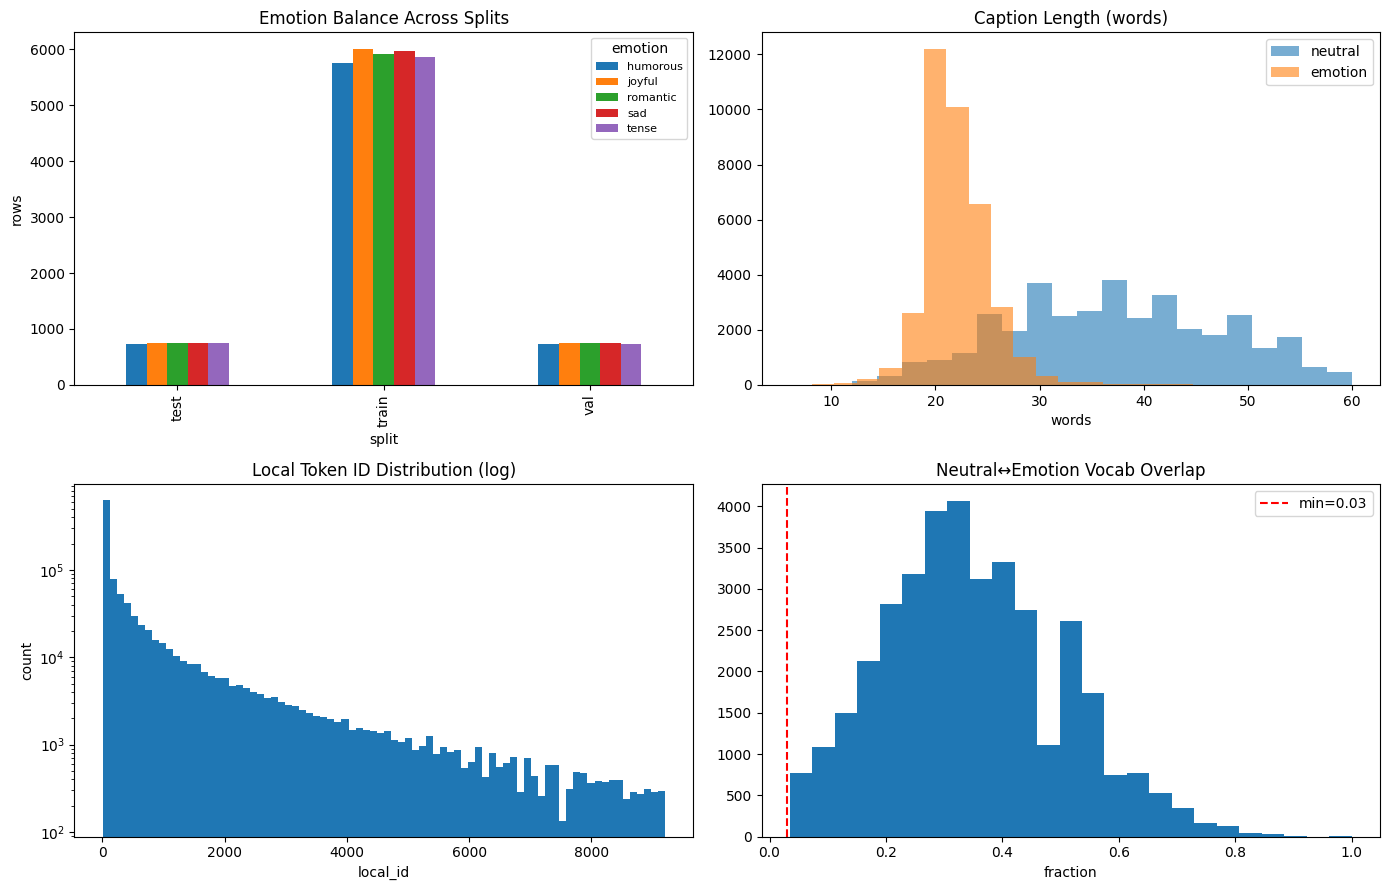

✅ Saved → /kaggle/working/tokenization_diagnostics.png


In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Emotion balance per split
emo_split = df.groupby(['split', 'emotion']).size().unstack(fill_value=0)
emo_split.plot(kind='bar', ax=axes[0, 0], stacked=False)
axes[0, 0].set(title='Emotion Balance Across Splits', ylabel='rows')
axes[0, 0].legend(title='emotion', fontsize=8)

# 2. Caption length distribution
axes[0, 1].hist(df['_n_words'], bins=20, alpha=0.6, label='neutral')
axes[0, 1].hist(df['_e_words'], bins=20, alpha=0.6, label='emotion')
axes[0, 1].set(title='Caption Length (words)', xlabel='words'); axes[0, 1].legend()

# 3. Token ID distribution (capped)
all_ids = []
for p in processed:
    all_ids.extend(p['emotion_local_token_ids'])
axes[1, 0].hist(all_ids, bins=80, log=True)
axes[1, 0].set(title='Local Token ID Distribution (log)', xlabel='local_id', ylabel='count')

# 4. Vocab overlap distribution
axes[1, 1].hist(df['_overlap'], bins=25)
axes[1, 1].axvline(MIN_VOCAB_OVERLAP, color='red', linestyle='--', label=f'min={MIN_VOCAB_OVERLAP}')
axes[1, 1].set(title='Neutral↔Emotion Vocab Overlap', xlabel='fraction'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/tokenization_diagnostics.png', dpi=120)
plt.show()
print(f"✅ Saved → {WORKING_DIR}/tokenization_diagnostics.png")